In [1]:
import pandas as pd
import numpy as np
data = pd.read_csv("../Dataset/Augmented_Cleaned_Data.csv")

In [2]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 507 entries, 0 to 506
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Place_Grew_Up           507 non-null    float64
 1   Price_Importance        507 non-null    float64
 2   Brand_Importance        507 non-null    float64
 3   Peer_Importance         507 non-null    float64
 4   Utility_Importance      507 non-null    float64
 5   Track_Bank_Balance      507 non-null    float64
 6   Track_None              507 non-null    float64
 7   Track_Payment_Apps      507 non-null    float64
 8   Track_Apps_Spreadsheet  507 non-null    float64
 9   Graph_Irregular_Random  507 non-null    float64
 10  Graph_Spike_Then_Low    507 non-null    float64
 11  Graph_High_Weekends     507 non-null    float64
 12  Graph_Uniform_Daily     507 non-null    float64
 13  Expenditure_Graph_nan   507 non-null    float64
 14  Emergency(JBS)          507 non-null    int64  
 15  

In [3]:
from sklearn.model_selection import train_test_split
y = data["Monthly_Spend"].values
X = data.drop(columns=["Monthly_Spend"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
from tensorflow.keras.models import Sequential # helps to stack layers in order
from tensorflow.keras.layers import Dense  # fully connected layers
from tensorflow.keras.utils import to_categorical  # converts integer label to classification vectors
from tensorflow.keras.layers import Dropout

In [5]:
y_train = y_train -1
y_test = y_test -1
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

In [6]:
model = Sequential([
    Dense(60, activation='relu',input_shape=(X_train.shape[1],)),
    #Dropout(0.2),
    #Dense(30, activation='relu'),
    Dropout(0.45),
    Dense(30, activation='relu'),
    
    Dense(20,activation='relu'),
    
    Dense(10,activation='softmax')
])

c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.compile(optimizer='adam', loss='categorical_crossentropy',metrics=['accuracy'])

In [8]:
model.fit(X_train, y_train_cat, epochs =40, batch_size=50, validation_split=0.20)

Epoch 1/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.0864 - loss: 2.5140 - val_accuracy: 0.1235 - val_loss: 2.2794
Epoch 2/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1049 - loss: 2.4086 - val_accuracy: 0.0741 - val_loss: 2.2477
Epoch 3/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1142 - loss: 2.3088 - val_accuracy: 0.1111 - val_loss: 2.2353
Epoch 4/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1451 - loss: 2.2674 - val_accuracy: 0.1111 - val_loss: 2.2266
Epoch 5/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1389 - loss: 2.2426 - val_accuracy: 0.1235 - val_loss: 2.2152
Epoch 6/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2006 - loss: 2.2270 - val_accuracy: 0.1358 - val_loss: 2.2053
Epoch 7/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2037 - loss: 2.2020 - val_accuracy: 0.1358 - val_loss: 2.1949
Epoch 8/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2160 - loss: 2.1748 - val_accuracy: 0.1728 - val_loss: 2.1823
Epoc

In [9]:
model.fit(X_train, y_train_cat, epochs =30, batch_size=30, validation_split=0.15)

Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5291 - loss: 1.1852 - val_accuracy: 0.4754 - val_loss: 1.3622
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5262 - loss: 1.1651 - val_accuracy: 0.5410 - val_loss: 1.3432
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5436 - loss: 1.1194 - val_accuracy: 0.4918 - val_loss: 1.3065
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5552 - loss: 1.1291 - val_accuracy: 0.5246 - val_loss: 1.2760
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5523 - loss: 1.1244 - val_accuracy: 0.5410 - val_loss: 1.2350
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5843 - loss: 1.0836 - val_accuracy: 0.5082 - val_loss: 1.2295
Epoch 7/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5785 - loss: 1.0635 - val_accuracy: 0.5082 - val_loss: 1.2104
Epoch 8/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5843 - loss: 1.0666 - val_accuracy: 0.5410 - val_loss:

In [10]:
model.fit(X_train, y_train_cat, epochs =30, batch_size=20, validation_split=0.15)

Epoch 1/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6948 - loss: 0.7882 - val_accuracy: 0.5738 - val_loss: 0.9456
Epoch 2/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6831 - loss: 0.7657 - val_accuracy: 0.6066 - val_loss: 0.8847
Epoch 3/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7035 - loss: 0.7214 - val_accuracy: 0.5574 - val_loss: 0.9110
Epoch 4/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6977 - loss: 0.7770 - val_accuracy: 0.6066 - val_loss: 0.8744
Epoch 5/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7297 - loss: 0.6937 - val_accuracy: 0.5738 - val_loss: 0.9069
Epoch 6/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6919 - loss: 0.7474 - val_accuracy: 0.5902 - val_loss: 0.8636
Epoch 7/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6977 - loss: 0.7358 - val_accuracy: 0.5574 - val_loss: 0.8993
Epoch 8/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7122 - loss: 0.7100 - val_accuracy: 0.5902 - val_loss:

In [11]:
model.fit(X_train, y_train_cat, epochs =30, batch_size=50, validation_split=0.15)

Epoch 1/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7733 - loss: 0.5333 - val_accuracy: 0.5738 - val_loss: 0.7910
Epoch 2/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7936 - loss: 0.5388 - val_accuracy: 0.5902 - val_loss: 0.7644
Epoch 3/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7907 - loss: 0.5579 - val_accuracy: 0.6230 - val_loss: 0.7447
Epoch 4/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8140 - loss: 0.5173 - val_accuracy: 0.6230 - val_loss: 0.7411
Epoch 5/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7703 - loss: 0.5755 - val_accuracy: 0.6066 - val_loss: 0.7501
Epoch 6/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7849 - loss: 0.5185 - val_accuracy: 0.6230 - val_loss: 0.7519
Epoch 7/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7762 - loss: 0.5343 - val_accuracy: 0.6230 - val_loss: 0.7572
Epoch 8/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8081 - loss: 0.5331 - val_accuracy: 0.6066 - val_loss: 0.7496
Ep

In [12]:
probs = model.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


In [13]:
print(np.round(probs[0],3))

[0.376 0.106 0.518 0.    0.    0.    0.    0.    0.    0.   ]


In [14]:
expected_spend = np.dot(probs[10], np.arange(10)+1)
print(f"Expected Monthly Spend (Risk Score): {expected_spend: .2f}")

Expected Monthly Spend (Risk Score):  5.22


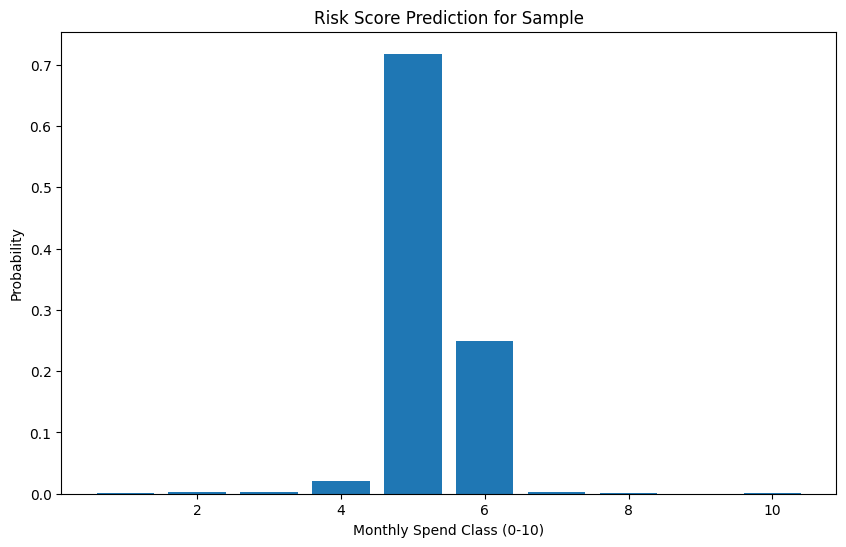

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.bar(np.arange(10)+1, probs[10])
plt.xlabel("Monthly Spend Class (0-10)")
plt.ylabel("Probability")
plt.title("Risk Score Prediction for Sample")
plt.show()